In [4]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [5]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [7]:
mu = 3.7
sigma = 0.46

In [8]:
# Seed the random number generator so we get the same results every time
np.random.seed(1)

In [9]:
sample = np.random.normal(mu, sigma, size=10)
sample

array([4.44719887, 3.41859205, 3.45704099, 3.20643443, 4.09808751,
       2.6412922 , 4.50261341, 3.34984483, 3.84675798, 3.58528963])

In [10]:
np.mean(sample), np.median(sample)

(np.float64(3.6553151902291945), np.float64(3.521165310619601))

In [11]:
def make_sample(n):
    return np.random.normal(mu, sigma, size=n)

In [12]:
ns = np.logspace(1, 5).astype(int)

In [13]:
means = [np.mean(make_sample(n)) for n in ns]

In [14]:
medians = [np.median(make_sample(n)) for n in ns]

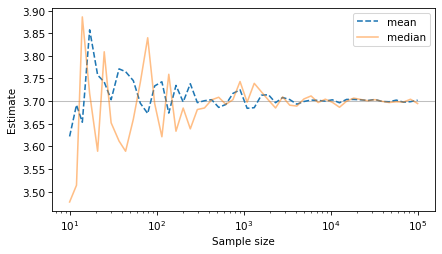

In [15]:
plt.axhline(mu, color="gray", lw=1, alpha=0.5)
plt.plot(ns, means, "--", label="mean")
plt.plot(ns, medians, alpha=0.5, label="median")

decorate(xlabel="Sample size", xscale="log", ylabel="Estimate")

In [16]:
means = [np.mean(make_sample(n=10)) for i in range(10001)]
np.mean(means)

np.float64(3.70034508492869)

In [17]:
medians = [np.median(make_sample(n=10)) for i in range(10001)]
np.mean(medians)

np.float64(3.701214089907223)

In [18]:
def mse(estimates, actual):
    """Mean squared error of a sequence of estimates."""
    errors = np.asarray(estimates) - actual
    return np.mean(errors**2)

In [19]:
mse(means, mu)

np.float64(0.020871984891289382)

In [20]:
mse(medians, mu)

np.float64(0.029022273128644173)

In [21]:
def mae(estimates, actual):
    """Mean absolute error of a sequence of estimates."""
    errors = np.asarray(estimates) - actual
    return np.mean(np.abs(errors))

In [22]:
mae(means, mu)

np.float64(0.11540433749505272)

In [23]:
mae(medians, mu)

np.float64(0.13654429774596036)

In [24]:
def make_sample_with_errors(n):
    sample = np.random.normal(mu, sigma, size=n)
    factor = np.random.choice([1, 2.2], p=[0.98, 0.02], size=n)
    return sample * factor

In [25]:
sample = make_sample_with_errors(n=1000)

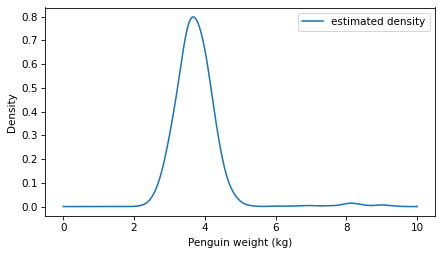

In [26]:
from scipy.stats import gaussian_kde
from thinkstats import Pdf

kde = gaussian_kde(sample)
domain = 0, 10
pdf = Pdf(kde, domain)
pdf.plot(label='estimated density')
decorate(xlabel="Penguin weight (kg)", ylabel="Density")

In [27]:
means = [np.mean(make_sample_with_errors(n=10)) for i in range(10001)]
np.mean(means)

np.float64(3.786352945690677)

In [28]:
medians = [np.median(make_sample_with_errors(n=10)) for i in range(10001)]
np.mean(medians)

np.float64(3.7121869836715353)

In [29]:
mse(means, mu), mse(medians, mu)

(np.float64(0.06853430354724438), np.float64(0.031164467796883758))

In [30]:
def biased_var(xs):
    # Compute variance with n in the denominator
    n = len(xs)
    deviations = xs - np.mean(xs)
    return np.sum(deviations**2) / n

In [31]:
biased_vars = [biased_var(make_sample(n=10)) for i in range(10001)]
np.mean(biased_vars)

np.float64(0.19049277659404473)

In [32]:
actual_var = sigma**2
actual_var

0.2116

In [33]:
def unbiased_var(xs):
    # Compute variance with n-1 in the denominator
    n = len(xs)
    deviations = xs - np.mean(xs)
    return np.sum(deviations**2) / (n - 1)

In [34]:
unbiased_vars = [unbiased_var(make_sample(n=10)) for i in range(10001)]
np.mean(unbiased_vars)

np.float64(0.21159109492300626)

In [35]:
n = 10
1 - (n - 1) / n

0.09999999999999998

In [36]:
n = 100
1 - (n - 1) / n

0.010000000000000009

In [37]:
download(
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins_raw.csv"
)

Downloaded penguins_raw.csv


In [38]:
penguins = pd.read_csv("penguins_raw.csv").dropna(subset=["Body Mass (g)"])
penguins.shape

(342, 17)

In [39]:
penguins["Species"].value_counts()

,count
Species,
Adelie Penguin (Pygoscelis adeliae),151
Gentoo penguin (Pygoscelis papua),123
Chinstrap penguin (Pygoscelis antarctica),68


In [40]:
chinstrap = penguins.query('Species.str.startswith("Chinstrap")')

In [41]:
def plot_kde(sample, name="estimated density", **options):
    kde = gaussian_kde(sample)
    m, s = np.mean(sample), np.std(sample)
    plt.axvline(m, color="gray", ls=":")

    domain = m - 4 * s, m + 4 * s
    pdf = Pdf(kde, domain, name)
    pdf.plot(**options)

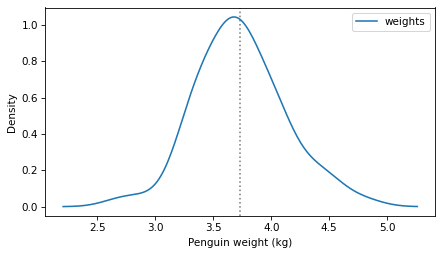

In [42]:
weights = chinstrap["Body Mass (g)"] / 1000
plot_kde(weights, "weights")
decorate(xlabel="Penguin weight (kg)", ylabel="Density")

In [43]:
sample_mean = np.mean(weights)
sample_mean

np.float64(3.733088235294118)

In [44]:
def resample(sample):
    # Generate a sample from a normal distribution
    m, s = np.mean(sample), np.std(sample)
    return np.random.normal(m, s, len(sample))

In [45]:
sample_means = [np.mean(resample(weights)) for i in range(1001)]

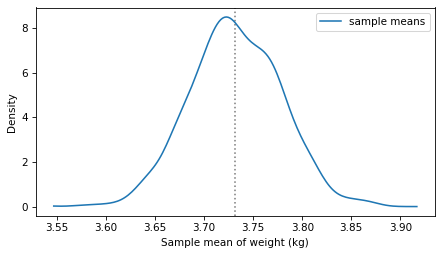

In [46]:
plot_kde(sample_means, "sample means")
decorate(xlabel="Sample mean of weight (kg)", ylabel="Density")

In [47]:
standard_error = np.std(sample_means)
standard_error

np.float64(0.04626531069684985)

In [48]:
np.std(weights)

0.3814986213564681

In [49]:
np.std(sample_means)

np.float64(0.04626531069684985)

In [50]:
def approximate_standard_error(sample):
    n = len(sample)
    return np.std(sample) / np.sqrt(n)

In [51]:
approximate_standard_error(weights)

np.float64(0.046263503290595163)

In [52]:
ci90 = np.percentile(sample_means, [5, 95])
ci90

array([3.6576334 , 3.80737506])

In [54]:
# Exercise 8.1

import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

import numpy as np

# assume df is your penguin dataset
# and column is "body_mass_g"

chinstrap = df[df["species"] == "Chinstrap"]["body_mass_g"].dropna()

# sample statistic
obs_std = chinstrap.std()

# bootstrap
n = len(chinstrap)
iters = 1000
stats = []

for _ in range(iters):
    sample = np.random.choice(chinstrap, size=n, replace=True)
    stats.append(np.std(sample))

stats = np.array(stats)

# standard error
se = stats.std()

# 90% confidence interval
ci = np.percentile(stats, [5, 95])

obs_std, se, ci

(384.3350813871914,
 np.float64(36.87697200046118),
 array([315.81725221, 437.62301457]))

In [55]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/CDBRFS08.ASC.gz")

Downloaded CDBRFS08.ASC.gz


In [56]:
from thinkstats import read_brfss

brfss = read_brfss()

In [57]:
male = brfss.query("sex == 1")
heights = male["htm3"]
heights.describe()

,htm3
count,154407.000000
mean,178.066221
std,7.723563
min,61.000000
25%,173.000000
50%,178.000000
75%,183.000000
max,236.000000


In [62]:
import numpy as np

# ----------------------------
# Step 1: simulate "male heights"
# (mean ~ 175 cm, std ~ 10 cm)
# ----------------------------
male = np.random.normal(loc=175, scale=10, size=1000)

# sample statistic
obs_mean = np.mean(male)

# ----------------------------
# Step 2: bootstrap resampling
# ----------------------------
n = len(male)
iters = 1000
stats = []

for _ in range(iters):
    sample = np.random.choice(male, size=n, replace=True)
    stats.append(np.mean(sample))

stats = np.array(stats)

# ----------------------------
# Step 3: compute results
# ----------------------------
se = stats.std()
ci = np.percentile(stats, [5, 95])

obs_mean, se, ci

(np.float64(174.59270703709205),
 np.float64(0.32472415418607814),
 array([174.02787673, 175.10021217]))

In [63]:
actual_mean = 10

In [64]:
def make_exponential(n):
    return np.random.exponential(actual_mean, size=n)

In [65]:
actual_median = np.log(2) * actual_mean
actual_median

np.float64(6.931471805599453)

In [66]:
# import numpy as np

true_mean = 10
n = 100
iters = 1000

mean_estimates = []
median_estimates = []

for _ in range(iters):
    sample = np.random.exponential(scale=true_mean, size=n)

    mean_estimates.append(np.mean(sample))
    median_estimates.append(np.median(sample))

mean_estimates = np.array(mean_estimates)
median_estimates = np.array(median_estimates)

# bias + variance comparison
mean_result = (mean_estimates.mean(), mean_estimates.std())
median_result = (median_estimates.mean(), median_estimates.std())

mean_result, median_result

((np.float64(10.016587140467484), np.float64(1.014165718214128)),
 (np.float64(7.015113130633615), np.float64(0.9887859296017667)))

In [67]:
def biased_std(sample):
    # Square root of the biased estimator of variance
    var = biased_var(sample)
    return np.sqrt(var)

In [68]:
def unbiased_std(sample):
    # Square root of the unbiased estimator of variance
    var = unbiased_var(sample)
    return np.sqrt(var)

In [69]:
# Here's an example using `make_sample`

mu, sigma = 3.7, 0.46
make_sample(n=10)

array([3.78676988, 4.38757372, 2.49516949, 3.60341076, 3.61767989,
       3.04125871, 4.06507216, 3.67678473, 3.25283506, 4.07987728])

In [72]:
import numpy as np

def make_sample(n=10):
    return np.random.normal(loc=3.7, scale=0.46, size=n)

iters = 1000

biased_sds = []
unbiased_sds = []

for _ in range(iters):
    sample = make_sample(10)

    # biased variance (ddof=0)
    biased_var = np.var(sample, ddof=0)
    biased_sds.append(np.sqrt(biased_var))

    # unbiased variance (ddof=1)
    unbiased_var = np.var(sample, ddof=1)
    unbiased_sds.append(np.sqrt(unbiased_var))

print("True SD:", 0.46)
print("Biased SD estimate mean:", np.mean(biased_sds))
print("Unbiased SD estimate mean:", np.mean(unbiased_sds))

True SD: 0.46
Biased SD estimate mean: 0.42119777725608004
Unbiased SD estimate mean: 0.4439814405098263


In [73]:
def estimate_tanks(sample):
    m = np.max(sample)
    k = len(sample)
    return m + (m - k) / k

In [74]:
N = 122
tanks = np.arange(1, N + 1)

In [75]:
def sample_tanks(k):
    return np.random.choice(tanks, replace=False, size=k)

In [76]:
np.random.seed(17)

In [77]:
sample = sample_tanks(5)
sample

array([74, 71, 95, 10, 17])

In [78]:
estimate_tanks(sample)

np.float64(113.0)

In [79]:
import numpy as np

def estimate_N(sample):
    k = len(sample)
    return max(sample) + (max(sample) / k) - 1

iters = 1000
true_N = 1000

estimates = []

for _ in range(iters):
    sample = np.random.choice(np.arange(1, true_N+1), size=20, replace=False)
    estimates.append(estimate_N(sample))

print("True N:", true_N)
print("Estimated mean:", np.mean(estimates))
print("Bias:", np.mean(estimates) - true_N)

True N: 1000
Estimated mean: 1001.5799000000001
Bias: 1.579900000000066


In [86]:
# Exercise 8.6

def make_hits_and_misses(n):
    # Generate a random sequence of 0s and 1s
    return np.random.choice([0, 1], size=n)

In [82]:
import numpy as np


def get_successors(seq, target_sum=3):
    """Get the successors of each subsequence that sums to a target value.

    Parameters:
    seq (array-like): Sequence of 1s and 0s.
    target_sum (int): The target sum of the subsequence. Default is 3.

    Returns:
    np.ndarray: Array of successors to subsequences that sum to `target_sum`.
    """
    # Check if the input sequence is too short
    if len(seq) < 3:
        return np.array([])

    # Compute the sum of each subsequence of length 3
    kernel = [1, 1, 1]
    corr = np.correlate(seq, kernel, mode="valid")

    # Find the indices where the subsequence sums to the target value
    indices = np.nonzero(corr == target_sum)[0]

    # Remove cases where the subsequence is at the end of the sequence
    indices = indices[indices < len(seq) - 3]

    # Find the successors of each valid subsequence
    successors = seq[indices + 3] if len(indices) > 0 else np.array([])

    return successors

In [83]:
def after_three_hits(seq):
    results = []

    for i in range(len(seq) - 3):
        if seq[i:i+3] == [1,1,1]:
            results.append(seq[i+3])

    return results

In [84]:
import numpy as np

def simulate(n=100):
    seq = list(np.random.choice([0,1], size=n))

    outcomes = after_three_hits(seq)

    if len(outcomes) == 0:
        return None

    return np.mean(outcomes)

iters = 5000
results = []

for _ in range(iters):
    r = simulate(100)
    if r is not None:
        results.append(r)

print("Average P(hit | 3 hits):", np.mean(results))

Average P(hit | 3 hits): 0.4580471698462715


In [85]:
for n in [20, 50, 100, 500]:
    results = []
    for _ in range(2000):
        r = simulate(n)
        if r is not None:
            results.append(r)

    print(n, np.mean(results))

20 0.358806483936523
50 0.4132825201723319
100 0.46228485767185457
500 0.49318356127359686
